# 🏠 CNN People Counter — Regression from Images

Train a CNN to estimate **how many people live in a picture** (200×200 px).  
The target is extracted from the **last number in each filename** (e.g. `house_district5_3.jpg` → target = **3**).

---

In [92]:
import os

import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import contextlib
import optuna
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm.auto import tqdm
from torch.nn import MSELoss

print(f"PyTorch {torch.__version__}")

# Device selection: prefer CUDA, then DirectML (Windows AMD), then MPS, else CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA available, GPU count:", torch.cuda.device_count())
    torch.backends.cudnn.benchmark = True
    use_amp = True
else:
    # Try DirectML (Windows + AMD GPUs) — install with `pip install torch-directml`
    try:
        import torch_directml
        dml_device = torch_directml.device()
        device = dml_device
        use_amp = False
        print("Using DirectML device:", device)
    except Exception:
        # Fall back to MPS (Apple) if available, otherwise CPU
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            device = torch.device("mps")
            use_amp = False
            print("Using device:", device)
        else:
            device = torch.device("cpu")
            use_amp = False
            print("Using device: cpu")

# pin_memory is only useful for CUDA; use it only when CUDA is active
PIN_MEMORY = getattr(device, 'type', '') == 'cuda'
print("pin_memory enabled:", PIN_MEMORY)

PyTorch 2.4.1+cpu
Using DirectML device: privateuseone:0
pin_memory enabled: False


In [93]:
import torch_directml
print(torch_directml.device_count())
for i in range(torch_directml.device_count()):
    print(i, torch_directml.device_name(i))
device = torch_directml.device(1)

2
0 AMD Radeon(TM) Graphics 
1 AMD Radeon RX 9070 XT 


## 1. Configuration

Adjust the settings below to match your setup.

In [94]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURE THESE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA_DIR    = "C:\\Users\\Ben12\\Documents\\GitHub\\AppML-Final-Project\\Data\\Data_All"   # ← change this
IMG_SIZE    = 200
BATCH_SIZE  = 16
NUM_SAMPLES = -1
EPOCHS      = 100
LR          = 4.5327389263135405e-05
WEIGHT_DECAY = 3.757594033791032e-05
VAL_SPLIT   = 0.2
DROPOUT     = 0.16851232433096264
PATIENCE    = 20       # early stopping patience
OUTPUT_DIR  = "output"
SEED        = 42
NUM_WORKERS = 0
TRAIN_POSITIVE_ONLY = True
BALANCE_DATASET = False

# Optuna controls
RUN_OPTUNA = True
RUN_ARCH_TUNING = True
OPTUNA_TRIALS = 50
OPTUNA_EPOCHS = 10
OPTUNA_TRAIN_SAMPLES = 3000
OPTUNA_VAL_SAMPLES = 1000
ARCH_OPTUNA_TRIALS = 50
ARCH_OPTUNA_EPOCHS = 8
ARCH_OPTUNA_TRAIN_SAMPLES = 3000
ARCH_OPTUNA_VAL_SAMPLES = 1000
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

#set random seed
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

## 2. Dataset

The target (number of people) is extracted from the **last number** in each filename before the extension.

| Filename | Target |
|---|---|
| `house_district5_3.jpg` | 3 |
| `img_001_12.png` | 12 |
| `photo-7.jpeg` | 7 |

In [95]:
def extract_target_from_filename(filename: str) -> int:
    """Return the last integer found in the filename (before extension)."""
    stem = Path(filename).stem
    numbers = re.findall(r"\d+", stem)
    if not numbers:
        raise ValueError(f"No numeric target found in filename: {filename}")
    return int(numbers[-1])


class PeopleCountDataset(Dataset):
    """Loads images from a directory; target = last number in filename."""

    VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    def __init__(self, root_dir: str, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for f in sorted(self.root_dir.iterdir()):
            if f.suffix.lower() in self.VALID_EXT:
                try:
                    target = extract_target_from_filename(f.name)
                    self.samples.append((f, target))
                except ValueError:
                    print(f"  ⚠ Skipping {f.name} — no target in name")

        if not self.samples:
            raise FileNotFoundError(
                f"No valid images in {root_dir}. Check the path and filename format."
            )

        targets = [t for _, t in self.samples]
        print(f"✓ Loaded {len(self.samples)} images")
        print(f"  Target range: {min(targets)} – {max(targets)}  "
              f"(mean {np.mean(targets):.1f}, std {np.std(targets):.1f})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert("L") # convert to grayscale
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(target, dtype=torch.float32)

## 3. Data Transforms & Loaders

In [96]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [97]:
# Load full dataset
full_dataset = PeopleCountDataset(DATA_DIR, transform=None)

if TRAIN_POSITIVE_ONLY:
    # Train only on samples with a known positive target.
    filtered_samples = [s for s in full_dataset.samples if s[1] > 0]
    print(f"Positive-only dataset: {len(filtered_samples)} samples (targets > 0)")
else:
    filtered_samples = list(full_dataset.samples)
    print(f"Full dataset: {len(filtered_samples)} samples (including zero targets)")

if BALANCE_DATASET:
    if TRAIN_POSITIVE_ONLY:
        # Optional: balance the positive-only dataset across exact target values.
        from collections import defaultdict

        by_target = defaultdict(list)
        for sample in filtered_samples:
            by_target[sample[1]].append(sample)

        min_count = min(len(samples) for samples in by_target.values())
        balanced_samples = []
        for target_value in sorted(by_target):
            random.shuffle(by_target[target_value])
            balanced_samples.extend(by_target[target_value][:min_count])

        filtered_samples = balanced_samples
        print(f"Balanced positive-only dataset: {len(filtered_samples)} total from {len(by_target)} target values")
    else:
        # Original behavior: balance zero-target vs nonzero-target samples.
        zero_samples = [s for s in filtered_samples if s[1] == 0]
        nonzero_samples = [s for s in filtered_samples if s[1] > 0]
        n_balanced = min(len(zero_samples), len(nonzero_samples))
        random.shuffle(zero_samples)
        random.shuffle(nonzero_samples)
        filtered_samples = zero_samples[:n_balanced] + nonzero_samples[:n_balanced]
        random.shuffle(filtered_samples)
        print(f"Balanced: {n_balanced} zero-people + {n_balanced} with-people = {len(filtered_samples)} total")

full_dataset.samples = filtered_samples
random.shuffle(full_dataset.samples)

if NUM_SAMPLES != -1:
    full_dataset.samples = full_dataset.samples[:NUM_SAMPLES]

val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_dataset = PeopleCountDataset(DATA_DIR, transform=train_transform)
train_dataset.samples = [full_dataset.samples[i] for i in train_subset.indices]

val_dataset = PeopleCountDataset.__new__(PeopleCountDataset)
val_dataset.root_dir = full_dataset.root_dir
val_dataset.transform = val_transform
val_dataset.samples = [full_dataset.samples[i] for i in val_subset.indices]

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
 )
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
 )

print(f"Train: {len(train_dataset)} samples  |  Val: {len(val_dataset)} samples")

✓ Loaded 88869 images
  Target range: 0 – 201  (mean 1.3, std 6.8)
Positive-only dataset: 9961 samples (targets > 0)
✓ Loaded 88869 images
  Target range: 0 – 201  (mean 1.3, std 6.8)
Train: 7969 samples  |  Val: 1992 samples


## 4. Quick EDA — Target Distribution

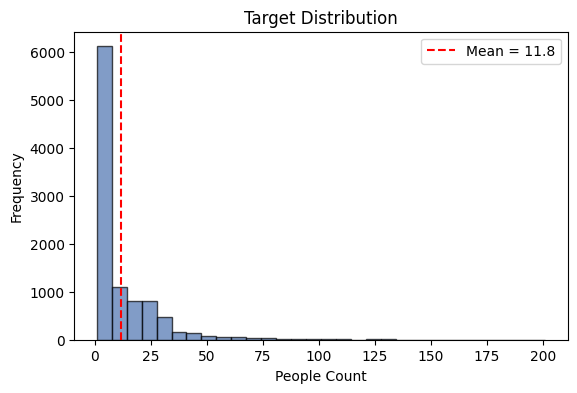

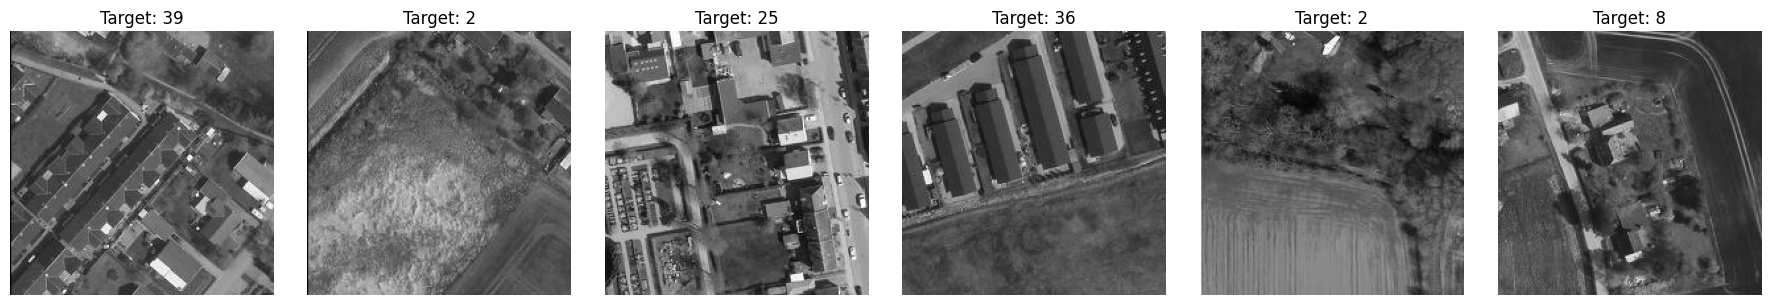

In [98]:
targets = [t for _, t in full_dataset.samples]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(targets, bins=30, edgecolor="black", alpha=0.7, color="#4C72B0")
axes[0].set_xlabel("People Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Target Distribution")
axes[0].axvline(np.mean(targets), color="red", linestyle="--", label=f"Mean = {np.mean(targets):.1f}")
axes[0].legend()

# Show a few sample images
sample_indices = random.sample(range(len(full_dataset)), min(6, len(full_dataset)))
axes[1].set_visible(False)

fig2, axes2 = plt.subplots(1, min(6, len(full_dataset)), figsize=(18, 3))
if not isinstance(axes2, np.ndarray):
    axes2 = [axes2]
for ax, idx in zip(axes2, sample_indices):
    path, target = full_dataset.samples[idx]
    img = Image.open(path).convert("L").resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Target: {target}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. CNN Model

4 convolutional blocks (Conv → BN → ReLU → MaxPool) with increasing filters (32 → 64 → 128 → 256), followed by adaptive average pooling and a 2-layer FC regression head.

In [99]:
class PeopleCountCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(1, 32),    # 200 → 100
            conv_block(32, 64),   # 100 → 50
            conv_block(64, 128),  #  50 → 25
            conv_block(128, 256), #  25 → 12
        )

        self.pool = nn.AdaptiveAvgPool2d(1)  # → 256×1×1

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x).squeeze(-1)


model = PeopleCountCNN(dropout=DROPOUT)
# If multiple CUDA GPUs are available, use DataParallel for simple multi-GPU utilization
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 1,206,625
PeopleCountCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
     

In [ ]:
if RUN_ARCH_TUNING:
    # ─────────────────────────────────────────────────────────────────────────
    # Architecture Search with Optuna
    #
    # Searches over:
    #   • num_conv_blocks  – depth of the CNN (2–5 blocks)
    #   • filters          – base filter count for block 1 (16 / 32 / 64)
    #   • filter_scale     – multiplier per block (1.5× or 2×)
    #   • double_conv      – whether each block uses two conv layers (like the
    #                        default model) or just one
    #   • fc_hidden        – size of the hidden FC layer (64 / 128 / 256 / 512)
    #   • use_extra_fc     – add a second hidden FC layer before the output
    #   • arch_dropout     – dropout applied in the FC head
    #
    # Training HPs (LR, batch size, weight decay) are fixed at whatever was
    # set/found in the config / Optuna HP search above so the architecture
    # signal is isolated.
    # ─────────────────────────────────────────────────────────────────────────

    class TunableCNN(nn.Module):
        """CNN whose architecture is fully controlled by keyword arguments."""

        def __init__(
            self,
            num_conv_blocks: int = 4,
            base_filters: int = 32,
            filter_scale: float = 2.0,
            double_conv: bool = True,
            fc_hidden: int = 128,
            use_extra_fc: bool = False,
            dropout: float = 0.3,
        ):
            super().__init__()

            def _block(in_c, out_c, double):
                layers = [
                    nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_c),
                    nn.ReLU(inplace=True),
                ]
                if double:
                    layers += [
                        nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                        nn.BatchNorm2d(out_c),
                        nn.ReLU(inplace=True),
                    ]
                layers.append(nn.MaxPool2d(2))
                return nn.Sequential(*layers)

            conv_blocks = []
            in_channels = 1
            out_channels = base_filters
            for _ in range(num_conv_blocks):
                out_channels = min(int(out_channels), 512)  # cap at 512
                conv_blocks.append(_block(in_channels, out_channels, double_conv))
                in_channels = out_channels
                out_channels = int(out_channels * filter_scale)

            self.features = nn.Sequential(*conv_blocks)
            self.pool = nn.AdaptiveAvgPool2d(1)

            head_layers = [
                nn.Flatten(),
                nn.Linear(in_channels, fc_hidden),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            if use_extra_fc:
                head_layers += [
                    nn.Linear(fc_hidden, fc_hidden // 2),
                    nn.ReLU(inplace=True),
                    nn.Dropout(dropout),
                ]
                head_layers.append(nn.Linear(fc_hidden // 2, 1))
            else:
                head_layers.append(nn.Linear(fc_hidden, 1))

            self.regressor = nn.Sequential(*head_layers)

        def forward(self, x):
            return self.regressor(self.pool(self.features(x))).squeeze(-1)


    def arch_objective(trial):
        # ── Architecture hyperparameters ──────────────────────────────────────
        num_conv_blocks = trial.suggest_int("num_conv_blocks", 2, 5)
        base_filters    = trial.suggest_categorical("base_filters", [16, 32, 64])
        filter_scale    = trial.suggest_categorical("filter_scale", [1.5, 2.0])
        double_conv     = trial.suggest_categorical("double_conv", [True, False])
        fc_hidden       = trial.suggest_categorical("fc_hidden", [64, 128, 256, 512])
        use_extra_fc    = trial.suggest_categorical("use_extra_fc", [True, False])
        arch_dropout    = trial.suggest_float("arch_dropout", 0.1, 0.5)

        # ── Build model ───────────────────────────────────────────────────────
        trial_model = TunableCNN(
            num_conv_blocks=num_conv_blocks,
            base_filters=base_filters,
            filter_scale=filter_scale,
            double_conv=double_conv,
            fc_hidden=fc_hidden,
            use_extra_fc=use_extra_fc,
            dropout=arch_dropout,
        ).to(device)

        # ── Fixed training HPs (reuse whatever was set/tuned earlier) ─────────
        trial_criterion  = MSELoss()
        trial_optimizer  = optim.AdamW(
            trial_model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            foreach=False,
        )

        # ── Subset loaders ────────────────────────────────────────────────────
        def _loader(dataset, n, shuffle):
            n = min(n, len(dataset))
            if n < len(dataset):
                subset, _ = random_split(
                    dataset,
                    [n, len(dataset) - n],
                    generator=torch.Generator().manual_seed(SEED),
                )
            else:
                subset = dataset
            return DataLoader(
                subset,
                batch_size=BATCH_SIZE,
                shuffle=shuffle,
                num_workers=NUM_WORKERS,
                pin_memory=PIN_MEMORY,
            )

        t_loader = _loader(train_dataset, ARCH_OPTUNA_TRAIN_SAMPLES, shuffle=True)
        v_loader = _loader(val_dataset,   ARCH_OPTUNA_VAL_SAMPLES,   shuffle=False)

        # ── Short training run ────────────────────────────────────────────────
        best_loss = float("inf")
        for epoch in range(ARCH_OPTUNA_EPOCHS):
            train_one_epoch(trial_model, t_loader, trial_criterion, trial_optimizer)
            val_loss, _, _, _, _ = evaluate(trial_model, v_loader, trial_criterion)

            trial.report(val_loss, epoch)
            # Delay pruning until past the halfway point to avoid killing
            # architectures that need a few epochs to warm up
            if epoch >= max(1, ARCH_OPTUNA_EPOCHS // 2) and trial.should_prune():
                raise optuna.TrialPruned()

            best_loss = min(best_loss, val_loss)

        return best_loss


    print("Starting architecture search...")
    arch_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=max(1, ARCH_OPTUNA_EPOCHS - 2),
        ),
    )
    arch_study.optimize(
        arch_objective,
        n_trials=ARCH_OPTUNA_TRIALS,
        show_progress_bar=True,
    )

    best_arch = arch_study.best_params
    print("\nBest architecture params:")
    for k, v in best_arch.items():
        print(f"  {k}: {v}")

    # ── Rebuild the main model with the winning architecture ──────────────────
    model = TunableCNN(
        num_conv_blocks=best_arch["num_conv_blocks"],
        base_filters=best_arch["base_filters"],
        filter_scale=best_arch["filter_scale"],
        double_conv=best_arch["double_conv"],
        fc_hidden=best_arch["fc_hidden"],
        use_extra_fc=best_arch["use_extra_fc"],
        dropout=best_arch["arch_dropout"],
    )
    if torch.cuda.is_available() and torch.cuda.device_count() > 1:
        model = torch.nn.DataParallel(model)
    model.to(device)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n✓ Architecture search complete — model rebuilt ({total_params:,} parameters)")
    print(model)

else:
    print("Architecture search skipped (RUN_ARCH_TUNING = False). Using default PeopleCountCNN.")
    model = PeopleCountCNN(dropout=DROPOUT).to(device)

[I 2026-06-05 13:44:39,886] A new study created in memory with name: no-name-983db794-7c5c-4bfd-a542-4b19f1386e7d


Starting architecture search...


  0%|          | 0/50 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

...

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

In [ ]:
if RUN_OPTUNA:
    def make_subset_loader(dataset, sample_size, batch_size, seed, shuffle):
        sample_size = min(sample_size, len(dataset))
        if sample_size == len(dataset):
            subset = dataset
        else:
            subset, _ = random_split(
                dataset,
                [sample_size, len(dataset) - sample_size],
                generator=torch.Generator().manual_seed(seed),
            )
        return DataLoader(
            subset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=NUM_WORKERS,
            pin_memory=PIN_MEMORY,
        )

    def objective(trial):
        trial_batch_size = trial.suggest_categorical("batch_size", [4, 16, 128])
        trial_lr = trial.suggest_float("lr", 5e-6, 3e-4, log=True)
        trial_dropout = trial.suggest_float("dropout", 0.05, 0.25)
        trial_weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-4, log

[I 2026-06-05 02:55:38,776] A new study created in memory with name: no-name-10b31352-a5c7-4893-91b3-ef7cf93ed90e


Starting Optuna search...


  0%|          | 0/100 [00:00<?, ?it/s]

  Training:   0%|          | 0/750 [00:00<?, ?it/s]

  Training:   0%|          | 0/750 [00:00<?, ?it/s]

...

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

  Training:   0%|          | 0/188 [00:00<?, ?it/s]

[I 2026-06-05 10:38:58,526] Trial 99 finished with value: 137.42851889038087 and parameters: {'batch_size': 16, 'lr': 8.365719718001936e-05, 'dropout': 0.19910922044198615, 'weight_decay': 4.23585255656855e-05}. Best is trial 29 with value: 129.97906581294538.

Best Optuna params:
{'batch_size': 4, 'lr': 8.528734814983025e-05, 'dropout': 0.20238212032019298, 'weight_decay': 1.2307619265611917e-05}

Rebuilding loaders and model with best params...


In [ ]:
=True)

        trial_train_loader = make_subset_loader(
            train_dataset, OPTUNA_TRAIN_SAMPLES, trial_batch_size, SEED, True
        )
        trial_val_loader = make_subset_loader(
            val_dataset, OPTUNA_VAL_SAMPLES, trial_batch_size, SEED, False
        )

        trial_model = PeopleCountCNN(dropout=trial_dropout).to(device)
        trial_criterion = MSELoss()
        trial_optimizer = optim.AdamW(
            trial_model.parameters(),
            lr=trial_lr,
            weight_decay=trial_weight_decay,
            foreach=False,
        )

        best_trial_loss = float("inf")
        for epoch in range(OPTUNA_EPOCHS):
            train_loss, train_mae = train_one_epoch(
                trial_model, trial_train_loader, trial_criterion, trial_optimizer
            )
            val_loss, val_mae, val_r2, _, _ = evaluate(
                trial_model, trial_val_loader, trial_criterion
            )
            trial.report(val_loss, epoch)
            # Allow pruning only after warmup epochs to avoid over-pruning
            if epoch >= max(1, OPTUNA_EPOCHS // 2):
                if trial.should_prune():
                    raise optuna.TrialPruned()
            best_trial_loss = min(best_trial_loss, val_loss)

        return best_trial_loss

    print("Starting Optuna search...")
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        # Make pruning less aggressive: more startup trials and longer warmup
        pruner=optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=max(1, OPTUNA_EPOCHS - 1)),
    )

    #Use default HPs as the first trial to ensure a strong baseline and good search space coverage
    study.enqueue_trial({
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "dropout": DROPOUT,
    "weight_decay": WEIGHT_DECAY,
    })

    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    print("\nBest Optuna params:")
    print(best_params)

    BATCH_SIZE = best_params["batch_size"]
    LR = best_params["lr"]
    DROPOUT = best_params["dropout"]
    WEIGHT_DECAY = best_params["weight_decay"]

    print("\nRebuilding loaders and model with best params...")
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    model = PeopleCountCNN(dropout=DROPOUT).to(device)
else:
    print("Optuna search skipped. Using configured hyperparameters.")
    model = PeopleCountCNN(dropout=DROPOUT).to(device)

## 6. Training

In [ ]:


criterion = MSELoss()
# Disable foreach/fused optimizer paths to reduce DirectML CPU fallbacks
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, foreach=False)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

In [ ]:
# MPS workaround: some ops need float32 fallback
if getattr(device, 'type', '') == "mps":
    import os
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Use AMP only when CUDA is available; provide no-op context otherwise
use_amp = (getattr(device, 'type', '') == "cuda")
scaler = torch.cuda.amp.GradScaler() if use_amp else None
autocast = torch.cuda.amp.autocast if use_amp else contextlib.nullcontext

def train_one_epoch(model, loader, criterion, optimizer, scaler=scaler):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in tqdm(loader, desc="  Training", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            preds = model(imgs)
            loss = criterion(preds, targets)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    return epoch_loss, mae


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in loader:
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with autocast():
            preds = model(imgs)
            loss = criterion(preds, targets)

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds) if len(set(all_targets)) > 1 else 0.0
    return epoch_loss, mae, r2, np.array(all_preds), np.array(all_targets)

In [ ]:
best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

pbar = tqdm(range(1, EPOCHS + 1), desc="Training")

for epoch in pbar:
    train_loss, train_mae = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_mae, val_r2, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    pbar.set_postfix({
        "t_loss": f"{train_loss:.4f}",
        "v_loss": f"{val_loss:.4f}",
        "v_mae": f"{val_mae:.2f}",
        "v_r2": f"{val_r2:.3f}",
    })

    # Early stopping + checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_mae": val_mae,
        }, os.path.join(OUTPUT_DIR, "best_model.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\n✓ Training complete — best val loss: {best_val_loss:.4f}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]

...

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]

  Training:   0%|          | 0/1993 [00:00<?, ?it/s]


⏹ Early stopping at epoch 73 (no improvement for 20 epochs)

✓ Training complete — best val loss: 86.7934


## 7. Training Curves

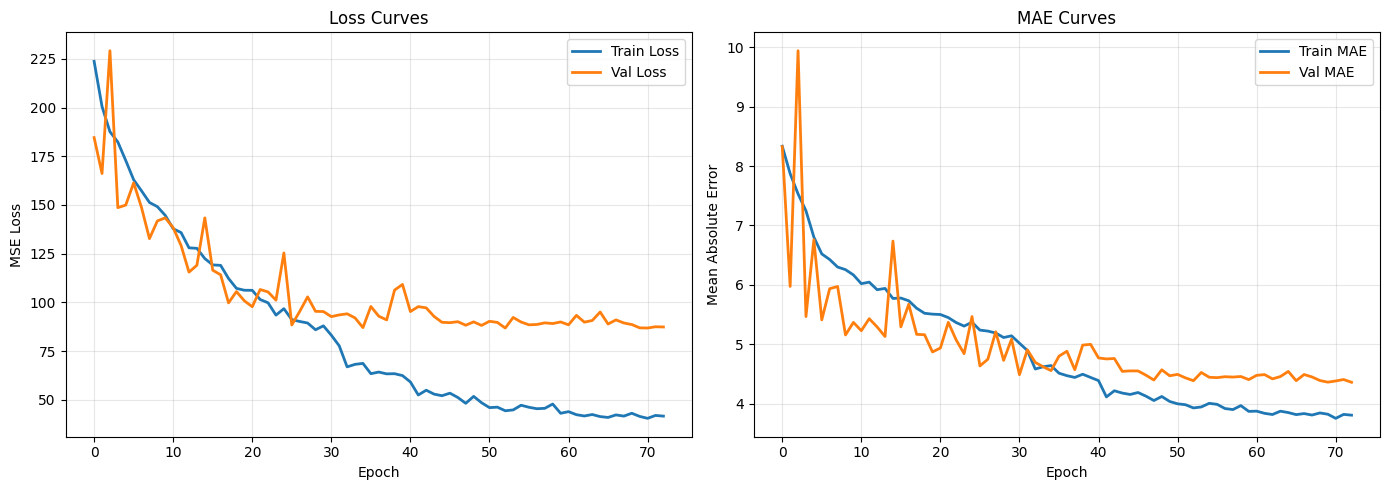

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_mae"], label="Train MAE", linewidth=2)
axes[1].plot(history["val_mae"], label="Val MAE", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_title("MAE Curves")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 8. Final Evaluation (Best Model)

In [ ]:
# Load best checkpoint
ckpt_path = os.path.join(OUTPUT_DIR, "best_model.pth")
try:
    # Load to CPU first; DirectML devices should not be used as map_location targets.
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
except Exception:
    # Fallback for older checkpoints or files that include unsupported objects.
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

val_loss, val_mae, val_r2, preds, targets = evaluate(model, val_loader, criterion)

print(f"Best model from epoch {ckpt['epoch']}:")
print(f"  Val MSE : {val_loss:.4f}")
print(f"  Val MAE : {val_mae:.2f}")
print(f"  Val R²  : {val_r2:.3f}")

Best model from epoch 53:
  Val MSE : 86.7934
  Val MAE : 4.38
  Val R²  : 0.704


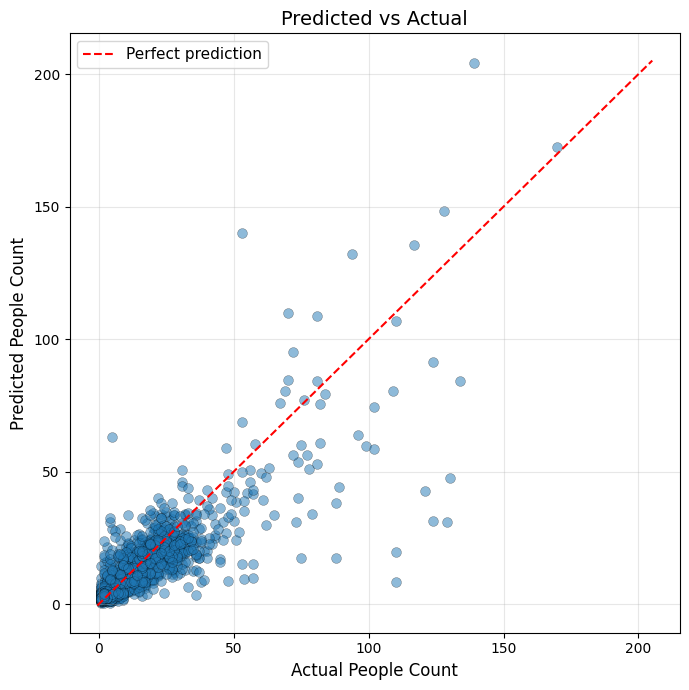

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(targets, preds, alpha=0.5, edgecolors="k", linewidth=0.3, s=50)
lims = [min(targets.min(), preds.min()) - 1,
        max(targets.max(), preds.max()) + 1]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual People Count", fontsize=12)
ax.set_ylabel("Predicted People Count", fontsize=12)
ax.set_title("Predicted vs Actual", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pred_vs_actual.png"), dpi=150)
plt.show()

## 9. Error Analysis

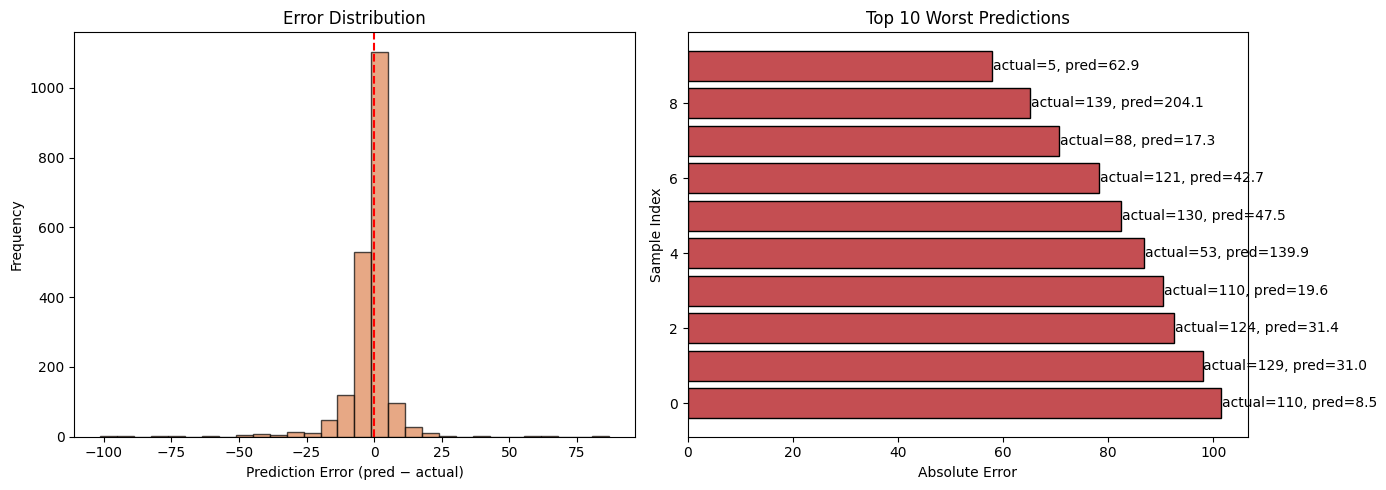

Median absolute error: 1.91
90th percentile error: 10.41
Within ±1 person:  27.6%
Within ±2 people:  51.8%


In [ ]:
errors = preds - targets
abs_errors = np.abs(errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=30, edgecolor="black", alpha=0.7, color="#DD8452")
axes[0].set_xlabel("Prediction Error (pred − actual)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Error Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Worst predictions
worst_idx = np.argsort(abs_errors)[-10:][::-1]
axes[1].barh(range(len(worst_idx)),
             abs_errors[worst_idx], color="#C44E52", edgecolor="black")
axes[1].set_xlabel("Absolute Error")
axes[1].set_ylabel("Sample Index")
axes[1].set_title("Top 10 Worst Predictions")
for i, idx in enumerate(worst_idx):
    axes[1].text(abs_errors[idx] + 0.1, i,
                 f"actual={targets[idx]:.0f}, pred={preds[idx]:.1f}", va="center")

plt.tight_layout()
plt.show()

print(f"Median absolute error: {np.median(abs_errors):.2f}")
print(f"90th percentile error: {np.percentile(abs_errors, 90):.2f}")
print(f"Within ±1 person:  {(abs_errors <= 1).mean()*100:.1f}%")
print(f"Within ±2 people:  {(abs_errors <= 2).mean()*100:.1f}%")

## 10. Inference on New Images

Use this cell to predict people count for any new image.

In [ ]:
@torch.no_grad()
def predict_image(image_path: str, model, transform, device):
    """Predict people count for a single image."""
    model.eval()
    img = Image.open(image_path).convert("L")
    tensor = transform(img).unsqueeze(0).to(device)
    prediction = model(tensor).item()
    return prediction, img


# Example usage (uncomment and set path):
# pred, img = predict_image("path/to/new_image.jpg", model, val_transform, device)
# plt.imshow(img.resize((IMG_SIZE, IMG_SIZE)))
# plt.title(f"Predicted: {pred:.1f} people")
# plt.axis("off")
# plt.show()